# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**


----

# Trabajo práctico entregable - parte 1


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
seaborn.set_context('talk')

In [ ]:
# Cargamos los datos
melb_df = pd.read_csv(
    'https://raw.githubusercontent.com/ro-dasilva/datos-colab/refs/heads/main/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


### Información acerca de las variables
Suburb: Suburb

Address: Dirección

Rooms: Número de habitaciones

Price: Precio en dólares australianos

Method:
S - propiedad vendida;
SP - propiedad vendida previamente;
PI - propiedad no vendida (pasó en subasta sin alcanzar el precio de reserva);
PN - vendida previamente no divulgada;
SN - vendida no divulgada;
NB - sin oferta;
VB - oferta del vendedor;
W - retirada antes de la subasta;
SA - vendida después de la subasta;
SS - vendida después de la subasta (precio no divulgado).
N/A - precio o oferta más alta no disponible.

Type:
br - dormitorio(s);
h - casa, cabaña, villa, semi-adosado, terraza;
u - unidad, dúplex;
t - casa adosada;
dev site - sitio de desarrollo;
o res - otra residencia.

SellerG: Agente inmobiliario

Date: Fecha de venta

Distance: Distancia al CBD en kilómetros

Regionname: Región general (Oeste, Noroeste, Norte, Noreste, etc.)

Propertycount: Número de propiedades existentes en el suburbio.

Bedroom2 : Número de dormitorios (obtenido de otra fuente)

Bathroom: Número de baños

Car: Número de plazas de aparcamiento

Landsize: Tamaño del terreno en metros cuadrados

BuildingArea: Superficie construida en metros cuadrados

YearBuilt: Año de construcción de la casa

CouncilArea: Área del consejo municipal

Lattitude: Latitud

Longtitude: Longitud


In [ ]:
melb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`.

2. Decidir si elimina algunas filas o columnas en base al análisis de datos faltantes.

3. Hacer un análisis descriptivo de las variables numéricas del conjunto de datos. Todas tienen el tipo `Dtype` correcto asignado? Armar una matriz (array) sólo con las variables numéricas.  

4. Estudiar las variables categóricas del DataFrame. Aplicar una codificación One-hot encoding a las columnas categóricas que crea pertinente. Si lo consideran necesario, pueden reducir el número de categorías únicas de algunas variables. ¿Cómo trataría la variable `Date`? Armar la matriz de variables categóricas codificada.

5. Concatenar la matriz de variables numéricas a la matriz que codifica las variables categóricas resultante del punto anterior.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


### Tratamiento de filas o columnas de datos faltantes

In [ ]:
# Crear una copia sin BuildingArea y YearBuilt
melb_df_ej1 = melb_df.drop(['BuildingArea', 'YearBuilt'], axis=1).copy()

In [ ]:
# Exploración general
melb_df_ej1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  CouncilArea    12211 non-null  object 
 15  Lattitude      13580 non-null  float64
 16  Longtitude     13580 non-null  float64
 17  Regionname     13580 non-null  object 
 18  Proper

In [ ]:
# Análisis descriptivo de variables numéricas
melb_df_ej1.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,-37.408530,145.526350,21650.000000


In [ ]:
# Conteo de valores faltantes
melb_df_ej1.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [ ]:
# Conteo de ceros
cols_cero = melb_df_ej1[melb_df_ej1 == 0].count(axis=0)
cols_cero[cols_cero > 0]

,0
Distance,6
Bedroom2,16
Bathroom,34
Car,1026
Landsize,1939


In [ ]:
melb_df_ej1.Car.describe()

,Car
count,13518.000000
mean,1.610075
std,0.962634
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,10.000000


En la variable **Car**, los valores faltantes parecen deberse a errores de registro, ya que el valor cero ya existe y representa propiedades sin cochera. Como la cantidad de faltantes es baja, se decide eliminar esas filas para no introducir supuestos adicionales.

In [ ]:
# Eliminamos columnas faltantes en la variable Car
melb_df_ej1 = melb_df_ej1.dropna(subset=['Car'])

In [ ]:
melb_df_ej1.shape[0]

13518

In [ ]:
# Conteo de valores faltantes
missing_values_count = melb_df_ej1.isna().sum()
missing_values_count[missing_values_count > 0]

,0
CouncilArea,1307


Como **CouncilArea** es una variable categórica, se decidió conservar los casos faltantes creando una nueva categoría, para no perder observaciones.

In [ ]:
melb_df_ej1['CouncilArea'] = melb_df_ej1['CouncilArea'].fillna('Desconocido')

In [ ]:
# Conteo de valores faltantes
melb_df_ej1.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


Variable Distance

In [ ]:
melb_df_ej1[melb_df_ej1['Distance'] == 0][['Suburb', 'Distance', 'Regionname']].head()

,Suburb,Distance,Regionname
9620,Melbourne,0.0,Northern Metropolitan
10393,Melbourne,0.0,Northern Metropolitan
10739,Melbourne,0.0,Northern Metropolitan
11428,Melbourne,0.0,Northern Metropolitan
12073,Melbourne,0.0,Northern Metropolitan


In [ ]:
melb_df_ej1[melb_df_ej1['Suburb'] == 'Melbourne']

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
3976,Melbourne,902/16 Liverpool St,1,u,427000.0,S,Harcourts,3/12/2016,2.8,3000.0,1.0,1.0,0.0,0.0,Melbourne,-37.81110,144.97150,Northern Metropolitan,17496.0
3977,Melbourne,14/2 Exhibition St,2,u,1160500.0,S,Kay,4/03/2017,2.8,3000.0,2.0,2.0,1.0,4230.0,Melbourne,-37.81570,144.97270,Northern Metropolitan,17496.0
3978,Melbourne,2306/265 Exhibition St,2,u,780000.0,SP,Galldon,4/06/2016,2.8,3000.0,2.0,2.0,1.0,0.0,Melbourne,-37.80950,144.96910,Northern Metropolitan,17496.0
3979,Melbourne,1501/87 Franklin St,2,u,535000.0,S,HAR,7/05/2016,2.8,3000.0,2.0,1.0,1.0,0.0,Melbourne,-37.80800,144.96170,Northern Metropolitan,17496.0
3980,Melbourne,3811/80 Abeckett St,2,u,450000.0,VB,MICM,7/11/2016,2.8,3000.0,2.0,1.0,1.0,0.0,Melbourne,-37.80910,144.96090,Northern Metropolitan,17496.0
3981,Melbourne,405/270 King St,2,u,360000.0,VB,LITTLE,7/11/2016,2.8,3000.0,2.0,1.0,0.0,0.0,Melbourne,-37.81380,144.95480,Northern Metropolitan,17496.0
3982,Melbourne,805/300 Swanston St,2,u,665000.0,S,Purplebricks,7/11/2016,2.8,3000.0,2.0,1.0,1.0,0.0,Melbourne,-37.81060,144.96460,Northern Metropolitan,17496.0
3983,Melbourne,1615/250 Elizabeth St,1,u,386000.0,S,Dingle,10/09/2016,2.8,3000.0,1.0,1.0,0.0,0.0,Melbourne,-37.81270,144.96270,Northern Metropolitan,17496.0
3984,Melbourne,49/2 Exhibition St,1,u,659000.0,S,Harcourts,10/09/2016,2.8,3000.0,1.0,1.0,1.0,0.0,Melbourne,-37.81570,144.97270,Northern Metropolitan,17496.0
3985,Melbourne,1/5 Davisons Pl,2,u,671000.0,SP,MICM,10/12/2016,2.8,3000.0,2.0,1.0,1.0,0.0,Melbourne,-37.80890,144.96700,Northern Metropolitan,17496.0


Se analizaron los registros con Distance = 0 y se observó que todos corresponden al suburbio Melbourne. Si bien no todas las propiedades de Melbourne tienen distancia cero, estos casos pueden interpretarse como propiedades ubicadas en la zona central de referencia, es decir en el centro principal de la ciudad. Por lo tanto, Distance = 0 se considera un valor válido y no un dato faltante.

Bedroom 2

En unidades tipo monoambiente puede ser válido, en casas es más raro.

In [ ]:
pd.crosstab(melb_df_ej1['Bedroom2'], melb_df_ej1['Rooms'])

Rooms,1,2,3,4,5,6,7,8,10
Bedroom2,,,,,,,,,
0.0,0,5,8,3,0,0,0,0,0
1.0,660,21,5,2,0,0,0,0,0
2.0,16,3513,162,19,1,0,0,0,0
3.0,2,74,5597,175,18,1,0,0,0
4.0,0,8,73,2469,42,4,0,1,0
5.0,0,1,5,15,531,2,2,0,0
6.0,0,0,0,0,2,59,0,2,0
7.0,0,0,0,0,1,1,8,0,0
8.0,0,0,0,0,1,0,0,4,0


In [ ]:
melb_df_ej1 = melb_df_ej1.drop('Bedroom2', axis=1)

Se elimina Bedroom2 porque presenta valores dudosos y además contiene información similar a Rooms. Dado que Rooms está completo y correctamente registrado, se conserva esta última como variable principal.

Bathroom

In [ ]:
pd.crosstab(melb_df['Bathroom'], melb_df['Rooms'])

Rooms,1,2,3,4,5,6,7,8,10
Bathroom,,,,,,,,,
0.0,1,19,11,3,0,0,0,0,0
1.0,674,3117,3250,452,17,2,0,0,0
2.0,6,504,2459,1720,260,20,3,2,0
3.0,0,8,153,469,244,35,5,2,1
4.0,0,0,5,41,47,9,2,2,0
5.0,0,0,1,2,25,0,0,0,0
6.0,0,0,2,0,2,1,0,0,0
7.0,0,0,0,0,1,0,0,1,0
8.0,0,0,0,1,0,0,0,1,0


In [ ]:
melb_df_ej1.loc[melb_df_ej1['Bathroom'] < 1, 'Bathroom'] = pd.NA
melb_df_ej1 = melb_df_ej1.dropna(subset=['Bathroom'])

Los valores Bathroom = 0 se consideran datos faltantes codificados como cero, ya que una propiedad habitable debería contar con al menos un baño. Como representan pocos casos, se eliminan esas filas.

<Axes: >

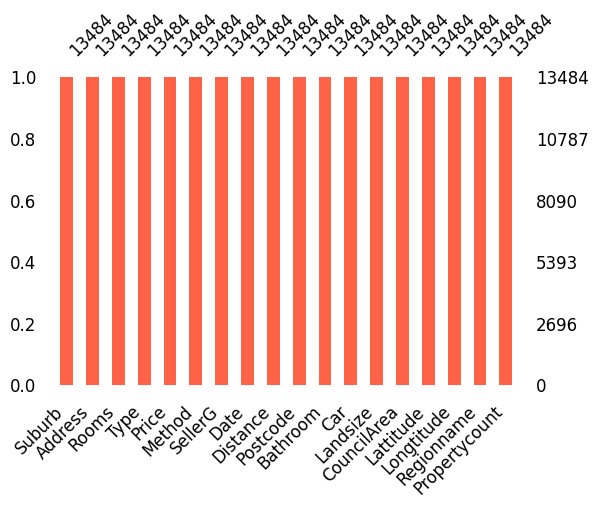

In [ ]:
import missingno as msno
msno.bar(melb_df_ej1,figsize=(6, 4), sort="ascending",fontsize=12, color='tomato')

### Análisis descriptivo variables numéricas

In [ ]:
melb_df_ej1.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


Al revisar los tipos de datos mediante dtypes, se observa que la mayoría de las variables tienen un tipo adecuado. Las variables categóricas aparecen como object, mientras que las variables cuantitativas aparecen como int64 o float64.

**Variables que conviene corregir:**

Date deberia tratarse como fecha

Postcode conceptualmente no es una variable numérica continua, sino un código postal.

In [ ]:
# Date como fecha
melb_df_ej1['Date'] = pd.to_datetime(melb_df_ej1['Date'], dayfirst=True)

melb_df_ej1['Year'] = melb_df_ej1['Date'].dt.year
melb_df_ej1['Month'] = melb_df_ej1['Date'].dt.month
melb_df_ej1['DayOfWeek'] = melb_df_ej1['Date'].dt.dayofweek

melb_df_ej1 = melb_df_ej1.drop('Date', axis=1)

# Postcode como categórica
melb_df_ej1['Postcode'] = melb_df_ej1['Postcode'].astype(str)

In [ ]:
melb_df_ej1.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Distance,float64
Postcode,object
Bathroom,float64


Armar matriz numérica

In [ ]:
numeric_cols = melb_df_ej1.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['Rooms', 'Price', 'Distance', 'Bathroom', 'Car', 'Landsize',
       'Lattitude', 'Longtitude', 'Propertycount'],
      dtype='object')

In [ ]:
melb_df_ej1[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Rooms,13484.0,2.940967e+00,0.956714,1.00000,2.00000,3.000000,3.000000e+00,1.000000e+01
Price,13484.0,1.075251e+06,640304.969219,85000.00000,650000.00000,901000.000000,1.330000e+06,9.000000e+06
Distance,13484.0,1.016466e+01,5.865301,0.00000,6.20000,9.200000,1.300000e+01,4.810000e+01
Bathroom,13484.0,1.539232e+00,0.688870,1.00000,1.00000,1.000000,2.000000e+00,8.000000e+00
Car,13484.0,1.614061e+00,0.960527,0.00000,1.00000,2.000000,2.000000e+00,1.000000e+01
Landsize,13484.0,5.588735e+02,4003.162685,0.00000,178.00000,443.000000,6.510000e+02,4.330140e+05
Lattitude,13484.0,-3.780915e+01,0.079414,-38.18255,-37.85700,-37.802200,-3.775610e+01,-3.740853e+01
Longtitude,13484.0,1.449953e+02,0.104086,144.43181,144.92923,145.000275,1.450586e+02,1.455264e+02
Propertycount,13484.0,7.454352e+03,4382.042359,249.00000,4380.00000,6567.000000,1.033100e+04,2.165000e+04


### Variables categóricas

In [ ]:
categorical_cols = melb_df.select_dtypes(include=['object']).columns
categorical_cols

Index(['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea',
       'Regionname'],
      dtype='object')

In [ ]:
melb_df[categorical_cols].nunique().sort_values(ascending=False)

,0
Address,13378
Suburb,314
SellerG,268
Date,58
CouncilArea,33
Regionname,8
Method,5
Type,3


Address tiene 13.378 direcciones distintas.

Suburb tiene 314 suburbios distintos.

SellerG tiene 268 agentes inmobiliarios distintos.

Type tiene solo 3 categorías.

Se decidió aplicar One-Hot Encoding solo a Type, Method y Regionname porque son variables categóricas con baja cardinalidad. Esto permite transformar la información cualitativa en variables numéricas sin generar una cantidad excesiva de columnas.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Variables categóricas elegidas para codificar
categorical_cols = ['Type', 'Method', 'Regionname']

# DataFrame solo con esas columnas
df_categoricas = melb_df_ej1[categorical_cols]

# One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_cat = encoder.fit_transform(df_categoricas)

# Ver tamaño de la matriz categórica codificada
X_cat.shape

(13484, 16)

In [ ]:
#columnas creadas
encoder.get_feature_names_out(categorical_cols)

array(['Type_h', 'Type_t', 'Type_u', 'Method_PI', 'Method_S', 'Method_SA',
       'Method_SP', 'Method_VB', 'Regionname_Eastern Metropolitan',
       'Regionname_Eastern Victoria', 'Regionname_Northern Metropolitan',
       'Regionname_Northern Victoria',
       'Regionname_South-Eastern Metropolitan',
       'Regionname_Southern Metropolitan',
       'Regionname_Western Metropolitan', 'Regionname_Western Victoria'],
      dtype=object)

### Concatenar la matriz de variables numéricas a la matriz que codifica las variables categóricas resultante del punto anterior.

In [ ]:
numeric_cols = melb_df_ej1.select_dtypes(include=['int64', 'float64']).columns

X_num = melb_df_ej1[numeric_cols].values

X_final = np.hstack([X_num, X_cat])

X_final.shape

(13484, 25)

## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer`, entre otros, para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos? Puede decidir si hacer PCA sobre todas las variables o bien seleccionar un subconjunto que crea pertinente.

2. Seleccione las proyecciones de los datos sobre las dos primeras componentes principales (las primeras dos columnas del resultado) para agregar como nuevas características al conjunto de datos.

## Ejercicio 4: Composición del resultado

Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

Para eso, será necesario recordar el nombre original de cada columna de la matriz, en el orden correcto. Tener en cuenta:
1. El método `OneHotEncoder.get_feature_names` o el atributo `OneHotEncoder.categories_` permiten obtener una lista con los valores de la categoría que le corresponde a cada índice de la matriz.
2. Ninguno de los métodos aplicados intercambia de lugar las columnas o las filas de la matriz.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

## Ejercicio 5: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas o columnas
  2. Interpretación de las columnas presentes
  2. Todas las transofrmaciones realizadas

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```
